CELL 1 — TITLE + OVERVIEW (Markdown)
# DeBERTaV3 Sentiment Classification Pipeline
## Stability-Focused Independent Transformer Investigation

This notebook is dedicated ONLY to DeBERTaV3 sentiment classification.

It intentionally avoids reusing unstable logic from previous mixed-model notebooks.

Previous experiments revealed:
- prediction collapse
- NaN eval losses
- misleading near-zero training loss
- tokenizer instability
- degenerate evaluation behavior

This notebook therefore prioritizes:
- stability
- observability
- reproducibility
- diagnostics
- artifact preservation

Primary goals:
1. Stable DeBERTaV3 fine-tuning
2. Explicit instability monitoring
3. Prediction-collapse detection
4. Robust evaluation
5. Exportable reusable artifacts


In [ ]:
!pip install -q transformers datasets evaluate accelerate
!pip install -q sentencepiece protobuf tiktoken
!pip install -q scikit-learn pandas matplotlib seaborn

In [ ]:
# CELL 3 — IMPORTS + GLOBAL SETUP

import os
import json
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    DataCollatorWithPadding,
    EvalPrediction
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# ============================================================
# GLOBAL SEEDING
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# DEVICE CHECK
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 60)
print("DEVICE:", DEVICE)

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA VERSION:", torch.version.cuda)

    total_mem = (
        torch.cuda.get_device_properties(0).total_memory / 1e9
    )

    reserved = torch.cuda.memory_reserved(0) / 1e9
    allocated = torch.cuda.memory_allocated(0) / 1e9

    print(f"GPU TOTAL MEMORY: {total_mem:.2f} GB")
    print(f"GPU RESERVED: {reserved:.2f} GB")
    print(f"GPU ALLOCATED: {allocated:.2f} GB")

print("=" * 60)

# ============================================================
# CONFIGURATION
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"

MAX_LENGTH = 256

BATCH_SIZE = 16

EPOCHS = 3

LEARNING_RATE = 2e-5

OUTPUT_DIR = "deberta_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("OUTPUT DIRECTORY READY:", OUTPUT_DIR)


DEVICE: cpu
OUTPUT DIRECTORY READY: deberta_outputs


LOADING DATASET WITH ROBUST PARSER
PASS: Dataset loaded successfully

RAW DATASET PREVIEW


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



DATASET SHAPE: (50000, 2)

COLUMNS DETECTED:
['review', 'sentiment']

RENAMED COLUMNS:
['text', 'label']

PASS: REQUIRED COLUMNS VERIFIED

NULL VALUE ANALYSIS
text     0
label    0
dtype: int64

REMOVED NULL ROWS: 0

RAW LABEL DISTRIBUTION
label
positive    25000
negative    25000
Name: count, dtype: int64

NUMERIC LABEL DISTRIBUTION
label
1    25000
0    25000
Name: count, dtype: int64

UNIQUE LABELS: [np.int64(0), np.int64(1)]

PASS: BINARY LABEL STRUCTURE VERIFIED

MINORITY/MAJORITY RATIO: 1.0000
PASS: CLASS DISTRIBUTION REASONABLY BALANCED

TEXT LENGTH STATISTICS
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64

VERY SHORT SAMPLES (<2 WORDS): 0
VERY LONG SAMPLES (>512 WORDS): 3694


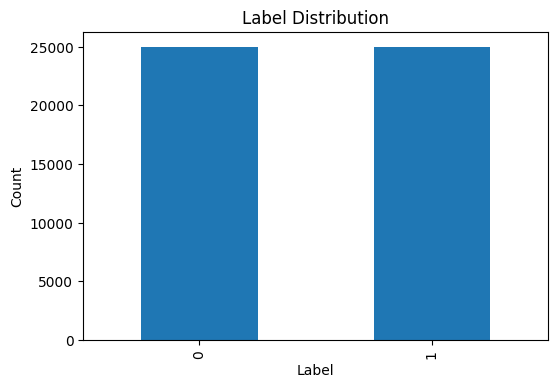


FINAL DATASET STATUS
FINAL SHAPE: (50000, 3)

DATASET VALIDATION COMPLETE


In [ ]:
# CELL 4 — DATASET LOADING + VALIDATION + BASIC ANALYSIS

# ============================================================
# ROBUST DATASET LOADING
# ============================================================

DATA_PATH = "/content/IMDB Dataset.csv"

print("=" * 60)
print("LOADING DATASET WITH ROBUST PARSER")
print("=" * 60)

try:

    df = pd.read_csv(
        DATA_PATH,
        engine="python",
        on_bad_lines="skip",
        encoding="utf-8"
    )

    print("PASS: Dataset loaded successfully")

except Exception as e:

    print("FAILED TO LOAD DATASET")
    print(e)

    raise e

# ============================================================
# RAW PREVIEW
# ============================================================

print("\n" + "=" * 60)
print("RAW DATASET PREVIEW")
print("=" * 60)

display(df.head())

print("\nDATASET SHAPE:", df.shape)

print("\nCOLUMNS DETECTED:")
print(df.columns.tolist())

# ============================================================
# HANDLE IMDB COLUMN FORMAT
# ============================================================

# Standard IMDB dataset typically uses:
# review -> text
# sentiment -> label

column_mapping = {}

if "review" in df.columns:
    column_mapping["review"] = "text"

if "sentiment" in df.columns:
    column_mapping["sentiment"] = "label"

df = df.rename(columns=column_mapping)

print("\nRENAMED COLUMNS:")
print(df.columns.tolist())

# ============================================================
# REQUIRED COLUMN CHECKS
# ============================================================

required_columns = ["text", "label"]

missing_cols = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_cols) > 0:

    raise ValueError(
        f"Missing required columns: {missing_cols}"
    )

print("\nPASS: REQUIRED COLUMNS VERIFIED")

# ============================================================
# NULL CHECKS
# ============================================================

print("\n" + "=" * 60)
print("NULL VALUE ANALYSIS")
print("=" * 60)

print(df.isnull().sum())

initial_rows = len(df)

df = df.dropna(subset=["text", "label"])

removed_rows = initial_rows - len(df)

print(f"\nREMOVED NULL ROWS: {removed_rows}")

# ============================================================
# TEXT CLEANING
# ============================================================

def clean_text(text):

    text = str(text)

    text = text.strip()

    text = " ".join(text.split())

    return text

df["text"] = df["text"].apply(clean_text)

# Remove empty samples
df = df[df["text"].str.len() > 0]

# ============================================================
# LABEL PROCESSING
# ============================================================

print("\n" + "=" * 60)
print("RAW LABEL DISTRIBUTION")
print("=" * 60)

print(df["label"].value_counts())

# Convert IMDB string labels -> numeric labels

label_mapping = {
    "negative": 0,
    "positive": 1
}

df["label"] = df["label"].map(label_mapping)

# ============================================================
# LABEL VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("NUMERIC LABEL DISTRIBUTION")
print("=" * 60)

print(df["label"].value_counts())

unique_labels = sorted(df["label"].dropna().unique())

print("\nUNIQUE LABELS:", unique_labels)

expected_labels = {0, 1}

if set(unique_labels) != expected_labels:

    raise ValueError(
        f"Expected binary labels {expected_labels}, "
        f"but found {set(unique_labels)}"
    )

print("\nPASS: BINARY LABEL STRUCTURE VERIFIED")

# ============================================================
# CLASS BALANCE CHECK
# ============================================================

label_counts = df["label"].value_counts()

minority_ratio = (
    label_counts.min() / label_counts.max()
)

print(f"\nMINORITY/MAJORITY RATIO: {minority_ratio:.4f}")

if minority_ratio < 0.30:
    print("WARNING: SIGNIFICANT CLASS IMBALANCE DETECTED")
else:
    print("PASS: CLASS DISTRIBUTION REASONABLY BALANCED")

# ============================================================
# TEXT LENGTH ANALYSIS
# ============================================================

df["word_count"] = df["text"].apply(
    lambda x: len(x.split())
)

print("\n" + "=" * 60)
print("TEXT LENGTH STATISTICS")
print("=" * 60)

print(df["word_count"].describe())

# ============================================================
# OUTLIER DETECTION
# ============================================================

very_short = (df["word_count"] < 2).sum()

very_long = (df["word_count"] > 512).sum()

print(f"\nVERY SHORT SAMPLES (<2 WORDS): {very_short}")

print(f"VERY LONG SAMPLES (>512 WORDS): {very_long}")

if very_short > 0:
    print("WARNING: Extremely short texts detected")

# ============================================================
# LABEL DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(6, 4))

df["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Label Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

# ============================================================
# FINAL DATASET STATUS
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATASET STATUS")
print("=" * 60)

print("FINAL SHAPE:", df.shape)

print("\nDATASET VALIDATION COMPLETE")

In [ ]:
# CELL 5 — TRAIN / VALIDATION / TEST SPLIT + HF DATASET CONVERSION

# ============================================================
# STRATIFIED TRAIN / VAL / TEST SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("=" * 60)
print("DATASET SPLITS")
print("=" * 60)

print(f"TRAIN SIZE: {len(train_df)}")
print(f"VALIDATION SIZE: {len(val_df)}")
print(f"TEST SIZE: {len(test_df)}")

# ============================================================
# DISTRIBUTION CHECKS
# ============================================================

print("\n" + "=" * 60)
print("LABEL DISTRIBUTION ACROSS SPLITS")
print("=" * 60)

print("\nTRAIN DISTRIBUTION")
print(train_df["label"].value_counts(normalize=True))

print("\nVALIDATION DISTRIBUTION")
print(val_df["label"].value_counts(normalize=True))

print("\nTEST DISTRIBUTION")
print(test_df["label"].value_counts(normalize=True))

# ============================================================
# RESET INDICES
# ============================================================

train_df = train_df.reset_index(drop=True)

val_df = val_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)

# ============================================================
# HF DATASET CONVERSION
# ============================================================

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]]
)

print("\n" + "=" * 60)
print("HF DATASET CONVERSION COMPLETE")
print("=" * 60)

print(train_dataset)
print(val_dataset)
print(test_dataset)

# ============================================================
# SAMPLE INSPECTION
# ============================================================

print("\n" + "=" * 60)
print("SAMPLE TRAIN EXAMPLE")
print("=" * 60)

sample_example = train_dataset[0]

print("TEXT:")
print(sample_example["text"][:500])

print("\nLABEL:")
print(sample_example["label"])

# ============================================================
# FINAL VALIDATION
# ============================================================

assert len(train_dataset) > 0
assert len(val_dataset) > 0
assert len(test_dataset) > 0

assert "text" in train_dataset.column_names
assert "label" in train_dataset.column_names

print("\nPASS: DATA SPLITS VERIFIED")

DATASET SPLITS
TRAIN SIZE: 40000
VALIDATION SIZE: 5000
TEST SIZE: 5000

LABEL DISTRIBUTION ACROSS SPLITS

TRAIN DISTRIBUTION
label
1    0.5
0    0.5
Name: proportion, dtype: float64

VALIDATION DISTRIBUTION
label
0    0.5
1    0.5
Name: proportion, dtype: float64

TEST DISTRIBUTION
label
0    0.5
1    0.5
Name: proportion, dtype: float64

HF DATASET CONVERSION COMPLETE
Dataset({
    features: ['text', 'label'],
    num_rows: 40000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})

SAMPLE TRAIN EXAMPLE
TEXT:
I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" havin

LOADING DEBERTA TOKENIZER


TOKENIZER LOADED SUCCESSFULLY

TOKENIZER CONFIGURATION
MODEL NAME: microsoft/deberta-v3-base
VOCAB SIZE: 128000
MODEL MAX LENGTH: 1000000000000000019884624838656
PAD TOKEN: [PAD]
PAD TOKEN ID: 0
CLS TOKEN: [CLS]
SEP TOKEN: [SEP]

SAMPLE TOKENIZATION
RAW TEXT:
I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile and nods. That made it even funnier! You gotta see "Chewabacca" played by what looks like a Muppet! It was extremely silly and stupid...but I couldn't stop laughing. Most of the dialogue was drowned out

TOKEN IDS:
[273, 2583, 291, 480, 10621

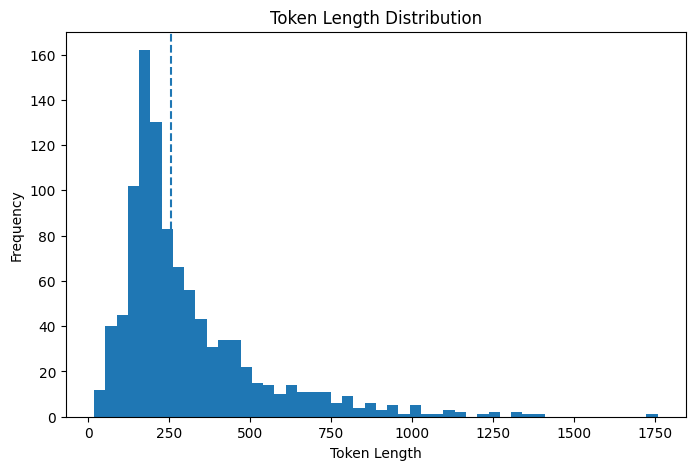


TOKENIZER STABILITY CHECK
PASS: TEST STRING 0
PASS: TEST STRING 1
PASS: TEST STRING 2
PASS: TEST STRING 3
PASS: TEST STRING 4

TOKENIZER DIAGNOSTICS COMPLETE


In [ ]:
# CELL 6 — TOKENIZER SETUP + TOKENIZATION DIAGNOSTICS

# ============================================================
# LOAD DEBERTA TOKENIZER
# ============================================================

print("=" * 60)
print("LOADING DEBERTA TOKENIZER")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False   # CRITICAL STABILITY REQUIREMENT
)

print("TOKENIZER LOADED SUCCESSFULLY")

# ============================================================
# TOKENIZER INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("TOKENIZER CONFIGURATION")
print("=" * 60)

print("MODEL NAME:", MODEL_NAME)

print("VOCAB SIZE:", tokenizer.vocab_size)

print("MODEL MAX LENGTH:", tokenizer.model_max_length)

print("PAD TOKEN:", tokenizer.pad_token)

print("PAD TOKEN ID:", tokenizer.pad_token_id)

print("CLS TOKEN:", tokenizer.cls_token)

print("SEP TOKEN:", tokenizer.sep_token)

# ============================================================
# SAMPLE TOKENIZATION
# ============================================================

sample_text = train_df["text"].iloc[0]

encoded_sample = tokenizer(
    sample_text,
    truncation=True,
    max_length=MAX_LENGTH
)

print("\n" + "=" * 60)
print("SAMPLE TOKENIZATION")
print("=" * 60)

print("RAW TEXT:")
print(sample_text[:700])

print("\nTOKEN IDS:")
print(encoded_sample["input_ids"][:50])

print("\nTOKENS:")
print(
    tokenizer.convert_ids_to_tokens(
        encoded_sample["input_ids"][:50]
    )
)

print("\nTOKEN COUNT:", len(encoded_sample["input_ids"]))

# ============================================================
# TOKEN LENGTH DISTRIBUTION ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("TOKEN LENGTH DISTRIBUTION ANALYSIS")
print("=" * 60)

sample_size = min(1000, len(train_df))

token_lengths = []

for text in train_df["text"].sample(
    sample_size,
    random_state=SEED
):

    ids = tokenizer(
        text,
        truncation=False
    )["input_ids"]

    token_lengths.append(len(ids))

token_lengths = np.array(token_lengths)

print("TOKEN LENGTH STATS")

print(f"MEAN: {token_lengths.mean():.2f}")

print(f"STD: {token_lengths.std():.2f}")

print(f"MIN: {token_lengths.min()}")

print(f"MAX: {token_lengths.max()}")

print(f"95TH PERCENTILE: {np.percentile(token_lengths, 95):.2f}")

print(f"99TH PERCENTILE: {np.percentile(token_lengths, 99):.2f}")

# ============================================================
# TRUNCATION ANALYSIS
# ============================================================

truncated_count = np.sum(
    token_lengths > MAX_LENGTH
)

truncation_ratio = (
    truncated_count / len(token_lengths)
)

print("\n" + "=" * 60)
print("TRUNCATION ANALYSIS")
print("=" * 60)

print(f"SAMPLES EXCEEDING MAX_LENGTH ({MAX_LENGTH}): {truncated_count}")

print(f"TRUNCATION RATIO: {truncation_ratio:.4f}")

if truncation_ratio > 0.25:
    print("WARNING: HIGH TRUNCATION RATE DETECTED")
else:
    print("PASS: TRUNCATION RATE ACCEPTABLE")

# ============================================================
# TOKEN LENGTH HISTOGRAM
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    token_lengths,
    bins=50
)

plt.axvline(
    MAX_LENGTH,
    linestyle="--"
)

plt.title("Token Length Distribution")

plt.xlabel("Token Length")

plt.ylabel("Frequency")

plt.show()

# ============================================================
# TOKENIZER STABILITY CHECK
# ============================================================

print("\n" + "=" * 60)
print("TOKENIZER STABILITY CHECK")
print("=" * 60)

test_strings = [
    "",
    "hello world",
    "🔥 unicode test 🔥",
    "A" * 1000,
    "<br /><br /> HTML TEST"
]

for idx, text in enumerate(test_strings):

    try:

        temp = tokenizer(text)

        print(f"PASS: TEST STRING {idx}")

    except Exception as e:

        print(f"FAIL: TEST STRING {idx}")
        print(e)

print("\nTOKENIZER DIAGNOSTICS COMPLETE")

In [ ]:
# CELL 7 — TOKENIZATION PIPELINE + DATASET ENCODING + ENCODING VALIDATION

# ============================================================
# TOKENIZATION FUNCTION
# ============================================================

def tokenize_function(batch):

    return tokenizer(
        batch["text"],

        truncation=True,

        max_length=MAX_LENGTH,

        padding=False   # dynamic padding later
    )

# ============================================================
# ENCODE DATASETS
# ============================================================

print("=" * 60)
print("ENCODING DATASETS")
print("=" * 60)

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    desc="Encoding Train Dataset"
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
    desc="Encoding Validation Dataset"
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    desc="Encoding Test Dataset"
)

print("\nPASS: DATASET ENCODING COMPLETE")

# ============================================================
# REMOVE UNUSED COLUMNS
# ============================================================

keep_columns = [
    "input_ids",
    "attention_mask",
    "label"
]

train_dataset = train_dataset.remove_columns(
    [
        col for col in train_dataset.column_names
        if col not in keep_columns
    ]
)

val_dataset = val_dataset.remove_columns(
    [
        col for col in val_dataset.column_names
        if col not in keep_columns
    ]
)

test_dataset = test_dataset.remove_columns(
    [
        col for col in test_dataset.column_names
        if col not in keep_columns
    ]
)

# ============================================================
# SET TORCH FORMAT
# ============================================================

train_dataset.set_format(
    type="torch",
    columns=keep_columns
)

val_dataset.set_format(
    type="torch",
    columns=keep_columns
)

test_dataset.set_format(
    type="torch",
    columns=keep_columns
)

print("\nPASS: TORCH DATASET FORMAT APPLIED")

# ============================================================
# DATA COLLATOR
# ============================================================

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

print("\nPASS: DATA COLLATOR INITIALIZED")

# ============================================================
# ENCODING VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("ENCODING VALIDATION")
print("=" * 60)

sample = train_dataset[0]

print("AVAILABLE KEYS:")
print(sample.keys())

print("\nINPUT_IDS SHAPE:")
print(sample["input_ids"].shape)

print("\nATTENTION_MASK SHAPE:")
print(sample["attention_mask"].shape)

print("\nLABEL:")
print(sample["label"])

print("\nLABEL DTYPE:")
print(type(sample["label"]))

# ============================================================
# TOKEN LENGTH POST-ENCODING
# ============================================================

encoded_lengths = []

sample_size = min(1000, len(train_dataset))

for i in range(sample_size):

    encoded_lengths.append(
        len(train_dataset[i]["input_ids"])
    )

encoded_lengths = np.array(encoded_lengths)

print("\n" + "=" * 60)
print("POST-ENCODING TOKEN LENGTH STATS")
print("=" * 60)

print(f"MEAN: {encoded_lengths.mean():.2f}")

print(f"STD: {encoded_lengths.std():.2f}")

print(f"MIN: {encoded_lengths.min()}")

print(f"MAX: {encoded_lengths.max()}")

# ============================================================
# HARD TRUNCATION VERIFICATION
# ============================================================

if encoded_lengths.max() > MAX_LENGTH:

    print("\nFAIL: TRUNCATION NOT ENFORCED")

else:

    print("\nPASS: MAX_LENGTH ENFORCED CORRECTLY")

# ============================================================
# LABEL DISTRIBUTION AFTER ENCODING
# ============================================================

train_labels = []

for i in range(len(train_dataset)):

    train_labels.append(
        int(train_dataset[i]["label"])
    )

encoded_label_dist = dict(
    Counter(train_labels)
)

print("\n" + "=" * 60)
print("LABEL DISTRIBUTION AFTER ENCODING")
print("=" * 60)

print(encoded_label_dist)

# ============================================================
# BATCH COLLATION TEST
# ============================================================

print("\n" + "=" * 60)
print("BATCH COLLATION TEST")
print("=" * 60)

test_batch = data_collator(
    [train_dataset[i] for i in range(4)]
)

for key, value in test_batch.items():

    print(f"{key}: {value.shape}")

# ============================================================
# NaN / INF CHECKS
# ============================================================

print("\n" + "=" * 60)
print("ENCODING NUMERICAL STABILITY CHECK")
print("=" * 60)

for key, tensor in test_batch.items():

    if tensor.dtype in [
        torch.float32,
        torch.float64
    ]:

        print(f"{key} NaN:",
              torch.isnan(tensor).any().item())

        print(f"{key} Inf:",
              torch.isinf(tensor).any().item())

print("\nENCODING VALIDATION COMPLETE")

ENCODING DATASETS


Encoding Train Dataset:   0%|          | 0/40000 [00:00<?, ? examples/s]

Encoding Validation Dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Encoding Test Dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]


PASS: DATASET ENCODING COMPLETE

PASS: TORCH DATASET FORMAT APPLIED

PASS: DATA COLLATOR INITIALIZED

ENCODING VALIDATION
AVAILABLE KEYS:
dict_keys(['label', 'input_ids', 'attention_mask'])

INPUT_IDS SHAPE:
torch.Size([207])

ATTENTION_MASK SHAPE:
torch.Size([207])

LABEL:
tensor(1)

LABEL DTYPE:
<class 'torch.Tensor'>

POST-ENCODING TOKEN LENGTH STATS
MEAN: 202.28
STD: 59.49
MIN: 25
MAX: 256

PASS: MAX_LENGTH ENFORCED CORRECTLY

LABEL DISTRIBUTION AFTER ENCODING
{1: 20000, 0: 20000}

BATCH COLLATION TEST
input_ids: torch.Size([4, 256])
attention_mask: torch.Size([4, 256])
labels: torch.Size([4])

ENCODING NUMERICAL STABILITY CHECK

ENCODING VALIDATION COMPLETE


In [ ]:
# CELL 8 — MODEL INITIALIZATION + PARAMETER VALIDATION + PRE-TRAINING STABILITY DIAGNOSTICS

# ============================================================
# LOAD DEBERTA MODEL
# ============================================================

print("=" * 60)
print("LOADING DEBERTA MODEL")
print("=" * 60)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(DEVICE)

print("PASS: MODEL LOADED SUCCESSFULLY")

# ============================================================
# MODEL ARCHITECTURE INFO
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFIER HEAD")
print("=" * 60)

print(model.classifier)

# ============================================================
# PARAMETER ANALYSIS
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

print("\n" + "=" * 60)
print("PARAMETER ANALYSIS")
print("=" * 60)

print(f"TOTAL PARAMETERS: {total_params:,}")

print(f"TRAINABLE PARAMETERS: {trainable_params:,}")

print(f"FROZEN PARAMETERS: {frozen_params:,}")

trainable_ratio = (
    trainable_params / total_params
)

print(f"TRAINABLE RATIO: {trainable_ratio:.4f}")

# ============================================================
# REQUIRES_GRAD VERIFICATION
# ============================================================

print("\n" + "=" * 60)
print("REQUIRES_GRAD VERIFICATION")
print("=" * 60)

requires_grad_failures = 0

for name, param in model.named_parameters():

    if not param.requires_grad:

        requires_grad_failures += 1

        print(f"WARNING: FROZEN PARAMETER -> {name}")

if requires_grad_failures == 0:
    print("PASS: ALL PARAMETERS TRAINABLE")
else:
    print(f"WARNING: {requires_grad_failures} FROZEN PARAMETERS DETECTED")

# ============================================================
# PRE-TRAINING DIAGNOSTIC BLOCK
# ============================================================

print("\n" + "=" * 60)
print("RUNNING PRE-TRAINING STABILITY DIAGNOSTICS")
print("=" * 60)

# Balanced diagnostic batch
diag_indices_0 = []
diag_indices_1 = []

for idx in range(len(train_dataset)):

    label = int(train_dataset[idx]["label"])

    if label == 0 and len(diag_indices_0) < 8:
        diag_indices_0.append(idx)

    if label == 1 and len(diag_indices_1) < 8:
        diag_indices_1.append(idx)

    if len(diag_indices_0) == 8 and len(diag_indices_1) == 8:
        break

diag_indices = diag_indices_0 + diag_indices_1

diagnostic_batch = data_collator(
    [train_dataset[i] for i in diag_indices]
)

diagnostic_batch = {
    k: v.to(DEVICE)
    for k, v in diagnostic_batch.items()
}

model.eval()

with torch.no_grad():

    outputs = model(
        input_ids=diagnostic_batch["input_ids"],
        attention_mask=diagnostic_batch["attention_mask"],
        labels=diagnostic_batch["labels"]
    )

    logits = outputs.logits

    loss = outputs.loss

# ============================================================
# MANUAL CROSS ENTROPY CHECK
# ============================================================

manual_loss = torch.nn.functional.cross_entropy(
    logits,
    diagnostic_batch["labels"]
)

print("\n" + "=" * 60)
print("LOSS VALIDATION")
print("=" * 60)

print("MODEL LOSS:", loss.item())

print("MANUAL LOSS:", manual_loss.item())

loss_diff = abs(
    loss.item() - manual_loss.item()
)

print("LOSS DIFFERENCE:", loss_diff)

if loss_diff < 1e-5:
    print("PASS: LOSS COMPUTATION CONSISTENT")
else:
    print("WARNING: LOSS COMPUTATION MISMATCH")

# ============================================================
# LOGIT STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("LOGIT STATISTICS")
print("=" * 60)

print("LOGIT SHAPE:", logits.shape)

print("MEAN:", logits.mean().item())

print("STD:", logits.std().item())

print("MIN:", logits.min().item())

print("MAX:", logits.max().item())

# ============================================================
# NaN / INF CHECKS
# ============================================================

print("\n" + "=" * 60)
print("NUMERICAL STABILITY CHECKS")
print("=" * 60)

logit_nan = torch.isnan(logits).any().item()

logit_inf = torch.isinf(logits).any().item()

loss_nan = torch.isnan(loss).item()

loss_inf = torch.isinf(loss).item()

print("NaN LOGITS:", logit_nan)

print("Inf LOGITS:", logit_inf)

print("NaN LOSS:", loss_nan)

print("Inf LOSS:", loss_inf)

if (
    logit_nan or
    logit_inf or
    loss_nan or
    loss_inf
):
    print("FAIL: NUMERICAL INSTABILITY DETECTED")
else:
    print("PASS: NUMERICAL STABILITY VERIFIED")

# ============================================================
# PREDICTION DISTRIBUTION CHECK
# ============================================================

preds = torch.argmax(
    logits,
    dim=1
)

pred_distribution = dict(
    Counter(preds.cpu().numpy())
)

print("\n" + "=" * 60)
print("PREDICTION DISTRIBUTION")
print("=" * 60)

print(pred_distribution)

unique_prediction_classes = len(pred_distribution)

print(
    "UNIQUE PREDICTED CLASSES:",
    unique_prediction_classes
)

if unique_prediction_classes == 1:

    print("WARNING: POSSIBLE EARLY PREDICTION COLLAPSE")

else:

    print("PASS: MULTI-CLASS PREDICTIONS DETECTED")

# ============================================================
# SOFTMAX PROBABILITY ANALYSIS
# ============================================================

probs = torch.softmax(
    logits,
    dim=1
)

max_probs = probs.max(dim=1).values

print("\n" + "=" * 60)
print("CONFIDENCE ANALYSIS")
print("=" * 60)

print("MEAN CONFIDENCE:", max_probs.mean().item())

print("STD CONFIDENCE:", max_probs.std().item())

print("MIN CONFIDENCE:", max_probs.min().item())

print("MAX CONFIDENCE:", max_probs.max().item())

# ============================================================
# EXTREME LOGIT DETECTION
# ============================================================

extreme_logits = (
    torch.abs(logits) > 100
).any().item()

print("\n" + "=" * 60)
print("EXTREME LOGIT CHECK")
print("=" * 60)

print("EXTREME LOGITS DETECTED:", extreme_logits)

if extreme_logits:
    print("WARNING: POSSIBLE EXPLODING LOGITS")
else:
    print("PASS: LOGIT MAGNITUDES REASONABLE")

# ============================================================
# FINAL DIAGNOSTIC STATUS
# ============================================================

print("\n" + "=" * 60)
print("PRE-TRAINING DIAGNOSTICS COMPLETE")
print("=" * 60)

LOADING DEBERTA MODEL


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias        

PASS: MODEL LOADED SUCCESSFULLY

CLASSIFIER HEAD
Linear(in_features=768, out_features=2, bias=True)

PARAMETER ANALYSIS
TOTAL PARAMETERS: 184,423,682
TRAINABLE PARAMETERS: 184,423,682
FROZEN PARAMETERS: 0
TRAINABLE RATIO: 1.0000

REQUIRES_GRAD VERIFICATION
PASS: ALL PARAMETERS TRAINABLE

RUNNING PRE-TRAINING STABILITY DIAGNOSTICS

LOSS VALIDATION
MODEL LOSS: 0.6900050640106201
MANUAL LOSS: 0.6904296875
LOSS DIFFERENCE: 0.0004246234893798828

LOGIT STATISTICS
LOGIT SHAPE: torch.Size([16, 2])
MEAN: -0.06268310546875
STD: 0.1522216796875
MIN: -0.455810546875
MAX: 0.317138671875

NUMERICAL STABILITY CHECKS
NaN LOGITS: False
Inf LOGITS: False
NaN LOSS: False
Inf LOSS: False
PASS: NUMERICAL STABILITY VERIFIED

PREDICTION DISTRIBUTION
{np.int64(0): 12, np.int64(1): 4}
UNIQUE PREDICTED CLASSES: 2
PASS: MULTI-CLASS PREDICTIONS DETECTED

CONFIDENCE ANALYSIS
MEAN CONFIDENCE: 0.546875
STD CONFIDENCE: 0.03240966796875
MIN CONFIDENCE: 0.50048828125
MAX CONFIDENCE: 0.61767578125

EXTREME LOGIT CHECK


In [ ]:
# CELL — FORCE FULL FP32 STABILITY MODE

torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

torch.set_default_dtype(torch.float32)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    torch_dtype=torch.float32
)

model = model.float().to(DEVICE)

for param in model.parameters():

    param.data = param.data.float()

print("MODEL DTYPE CHECK:")

dtypes = set()

for param in model.parameters():
    dtypes.add(param.dtype)

print(dtypes)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-6,
    eps=1e-6
)

print("PASS: FORCED FP32 SAFE MODE ENABLED")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias        

MODEL DTYPE CHECK:
{torch.float32}
PASS: FORCED FP32 SAFE MODE ENABLED


In [ ]:
# CELL 9 — METRICS PIPELINE + CUSTOM STABILITY CALLBACK + TRAINING CONFIGURATION

# ============================================================
# METRICS FUNCTION
# ============================================================

def compute_metrics(eval_pred):

    predictions = eval_pred.predictions

    labels = eval_pred.label_ids

    # --------------------------------------------------------
    # HANDLE TUPLE PREDICTIONS
    # --------------------------------------------------------

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # --------------------------------------------------------
    # NaN / INF SANITIZATION
    # --------------------------------------------------------

    nan_count = np.isnan(predictions).sum()

    inf_count = np.isinf(predictions).sum()

    if nan_count > 0:
        print(f"WARNING: NaN VALUES IN PREDICTIONS -> {nan_count}")

    if inf_count > 0:
        print(f"WARNING: Inf VALUES IN PREDICTIONS -> {inf_count}")

    predictions = np.nan_to_num(
        predictions,
        nan=0.0,
        posinf=1e4,
        neginf=-1e4
    )

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    preds = np.argmax(
        predictions,
        axis=1
    )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        labels,
        preds
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            preds,
            average="binary",
            zero_division=0
        )
    )

    # --------------------------------------------------------
    # PREDICTION DISTRIBUTION
    # --------------------------------------------------------

    pred_distribution = dict(
        Counter(preds.tolist())
    )

    print("\n" + "=" * 60)
    print("EVALUATION PREDICTION DISTRIBUTION")
    print("=" * 60)

    print(pred_distribution)

    # --------------------------------------------------------
    # COLLAPSE DETECTION
    # --------------------------------------------------------

    if len(pred_distribution) == 1:

        print("WARNING: ONE-CLASS COLLAPSE DETECTED")

    majority_ratio = (
        max(pred_distribution.values()) /
        sum(pred_distribution.values())
    )

    print(f"MAJORITY CLASS RATIO: {majority_ratio:.4f}")

    if majority_ratio > 0.95:
        print("WARNING: EXTREME PREDICTION DOMINANCE")

    # --------------------------------------------------------
    # LOGIT STATISTICS
    # --------------------------------------------------------

    print("\nLOGIT STATISTICS")

    print("MEAN:", predictions.mean())

    print("STD:", predictions.std())

    print("MIN:", predictions.min())

    print("MAX:", predictions.max())

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ============================================================
# CUSTOM STABILITY CALLBACK
# ============================================================

class StabilityCallback(TrainerCallback):

    def on_log(
        self,
        args,
        state,
        control,
        logs=None,
        **kwargs
    ):

        if logs is None:
            return

        print("\n" + "=" * 60)
        print(f"TRAINER LOG STEP: {state.global_step}")
        print("=" * 60)

        for key, value in logs.items():

            print(f"{key}: {value}")

            if isinstance(value, float):

                if np.isnan(value):
                    print(f"WARNING: NaN DETECTED IN {key}")

                if np.isinf(value):
                    print(f"WARNING: Inf DETECTED IN {key}")

                if abs(value) > 1e4:
                    print(f"WARNING: EXTREME VALUE DETECTED IN {key}")

    # --------------------------------------------------------
    # EVALUATION MONITORING
    # --------------------------------------------------------

    def on_evaluate(
        self,
        args,
        state,
        control,
        metrics=None,
        **kwargs
    ):

        print("\n" + "=" * 60)
        print("POST-EVALUATION STABILITY CHECK")
        print("=" * 60)

        if metrics is not None:

            for key, value in metrics.items():

                print(f"{key}: {value}")

                if isinstance(value, float):

                    if np.isnan(value):
                        print(f"WARNING: NaN METRIC -> {key}")

                    if np.isinf(value):
                        print(f"WARNING: Inf METRIC -> {key}")

        print("=" * 60)

# ============================================================
# TRAINING ARGUMENTS
# ============================================================

training_args = TrainingArguments(

    # --------------------------------------------------------
    # OUTPUTS
    # --------------------------------------------------------

    output_dir=OUTPUT_DIR,

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    num_train_epochs=EPOCHS,

    learning_rate=LEARNING_RATE, # Use global LEARNING_RATE

    weight_decay=0.01,

    max_grad_norm=0.5,

    warmup_ratio=0.1,

    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=BATCH_SIZE,

    gradient_accumulation_steps=1,

    optim="adamw_torch",

    lr_scheduler_type="linear",

    # --------------------------------------------------------
    # EVALUATION / SAVING
    # --------------------------------------------------------

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    save_total_limit=2,

    # --------------------------------------------------------
    # LOGGING
    # --------------------------------------------------------

    logging_steps=50,

    logging_dir=f"{OUTPUT_DIR}/logs",

    logging_nan_inf_filter=False,

    report_to="none",

    # --------------------------------------------------------
    # MIXED PRECISION
    # --------------------------------------------------------

    fp16=False,

    # --------------------------------------------------------
    # REPRODUCIBILITY
    # --------------------------------------------------------

    seed=SEED,

    data_seed=SEED,

    # --------------------------------------------------------
    # DATALOADER
    # --------------------------------------------------------

    dataloader_num_workers=2,

    # --------------------------------------------------------
    # STABILITY
    # --------------------------------------------------------

    remove_unused_columns=False
)

print("=" * 60)
print("TRAINING ARGUMENTS INITIALIZED")
print("=" * 60)

print(training_args)

# ============================================================
# TRAINER INITIALIZATION
# ============================================================

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[StabilityCallback()]
)

print("\nPASS: TRAINER INITIALIZED SUCCESSFULLY")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TRAINING ARGUMENTS INITIALIZED
TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=42,
dataloader_drop_last=False,
dataloader_num_workers=2,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH

In [ ]:
# CELL 10 — TRAINING EXECUTION + LIVE STABILITY MONITORING

# ============================================================
# INITIAL GPU MEMORY STATUS
# ============================================================

print("=" * 60)
print("INITIAL GPU MEMORY STATUS")
print("=" * 60)

if torch.cuda.is_available():

    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9

    print(f"ALLOCATED GPU MEMORY: {allocated:.2f} GB")
    print(f"RESERVED GPU MEMORY: {reserved:.2f} GB")

# ============================================================
# TRAINING START
# ============================================================

print("\n" + "=" * 60)
print("STARTING DEBERTA TRAINING")
print("=" * 60)

print(f"MODEL: {MODEL_NAME}")

print(f"EPOCHS: {EPOCHS}")

print(f"BATCH SIZE: {BATCH_SIZE}")

print(f"LEARNING RATE: {LEARNING_RATE}")

print(f"MAX LENGTH: {MAX_LENGTH}")

print("=" * 60)

# ============================================================
# TRAIN MODEL
# ============================================================

train_result = trainer.train()

# ============================================================
# TRAINING COMPLETE
# ============================================================

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

# ============================================================
# FINAL TRAIN METRICS
# ============================================================

print("\nFINAL TRAINING METRICS")

print(train_result.metrics)

# ============================================================
# SAVE TRAINING METRICS
# ============================================================

with open(
    f"{OUTPUT_DIR}/train_metrics.json",
    "w"
) as f:

    json.dump(
        train_result.metrics,
        f,
        indent=2
    )

print("\nPASS: TRAIN METRICS SAVED")

# ============================================================
# SAVE TRAINING HISTORY
# ============================================================

training_history = trainer.state.log_history

with open(
    f"{OUTPUT_DIR}/training_history.json",
    "w"
) as f:

    json.dump(
        training_history,
        f,
        indent=2
    )

print("PASS: TRAINING HISTORY SAVED")

# ============================================================
# POST-TRAINING GPU STATUS
# ============================================================

print("\n" + "=" * 60)
print("POST-TRAINING GPU STATUS")
print("=" * 60)

if torch.cuda.is_available():

    allocated = torch.cuda.memory_allocated() / 1e9

    reserved = torch.cuda.memory_reserved() / 1e9

    max_allocated = (
        torch.cuda.max_memory_allocated() / 1e9
    )

    print(f"CURRENT ALLOCATED: {allocated:.2f} GB")

    print(f"CURRENT RESERVED: {reserved:.2f} GB")

    print(f"PEAK GPU MEMORY: {max_allocated:.2f} GB")

# ============================================================
# TRAINING LOSS TREND VISUALIZATION
# ============================================================

train_losses = []

eval_losses = []

steps_train = []

steps_eval = []

for log in training_history:

    if "loss" in log:

        train_losses.append(log["loss"])

        steps_train.append(log["step"])

    if "eval_loss" in log:

        eval_losses.append(log["eval_loss"])

        steps_eval.append(log["step"])

print("\n" + "=" * 60)
print("TRAINING LOSS ANALYSIS")
print("=" * 60)

print(f"TRAIN LOSS POINTS: {len(train_losses)}")

print(f"EVAL LOSS POINTS: {len(eval_losses)}")

# ============================================================
# NaN / INF LOSS CHECKS
# ============================================================

train_nan = np.isnan(train_losses).any()

eval_nan = np.isnan(eval_losses).any()

train_inf = np.isinf(train_losses).any()

eval_inf = np.isinf(eval_losses).any()

print("\nNaN TRAIN LOSSES:", train_nan)

print("NaN EVAL LOSSES:", eval_nan)

print("INF TRAIN LOSSES:", train_inf)

print("INF EVAL LOSSES:", eval_inf)

if (
    train_nan or
    eval_nan or
    train_inf or
    eval_inf
):
    print("\nWARNING: NUMERICAL INSTABILITY DETECTED")
else:
    print("\nPASS: LOSS CURVES NUMERICALLY STABLE")

# ============================================================
# LOSS CURVE PLOT
# ============================================================

plt.figure(figsize=(10, 5))

if len(train_losses) > 0:

    plt.plot(
        steps_train,
        train_losses,
        label="Train Loss"
    )

if len(eval_losses) > 0:

    plt.plot(
        steps_eval,
        eval_losses,
        label="Eval Loss"
    )

plt.xlabel("Training Step")

plt.ylabel("Loss")

plt.title("Training / Evaluation Loss Curves")

plt.legend()

plt.show()

# ============================================================
# COLLAPSE WARNING ANALYSIS
# ============================================================

if len(train_losses) > 2:

    if min(train_losses) < 1e-4:

        print("\nWARNING: EXTREMELY LOW TRAIN LOSS DETECTED")
        print("Possible memorization or instability")

print("\nTRAINING PIPELINE COMPLETE")

INITIAL GPU MEMORY STATUS


NameError: name 'torch' is not defined

In [ ]:
# CELL 11 — FORENSIC NAN/GRADIENT INVESTIGATION (PRE-TRAINING)

# ============================================================
# PURPOSE
# ============================================================
# This cell isolates:
#
# 1. bad batches
# 2. exploding gradients
# 3. invalid logits
# 4. optimizer corruption
# 5. label issues
#
# BEFORE full training.
#
# We intentionally perform controlled manual steps.
# ============================================================

from torch.utils.data import DataLoader

print("=" * 60)
print("STARTING FORENSIC STABILITY INVESTIGATION")
print("=" * 60)

# ============================================================
# FRESH MODEL
# ============================================================

# Ensure the previous model is properly cleaned up before re-initialization
if 'model' in locals():
    del model
torch.cuda.empty_cache()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(DEVICE)

model.train()

print("PASS: Fresh model initialized")

# ============================================================
# SAFE OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-6
)

print("PASS: Safe AdamW optimizer initialized")

# ============================================================
# DATALOADER
# ============================================================

debug_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=data_collator
)

print("PASS: Debug dataloader created")

# ============================================================
# GLOBAL TRACKERS
# ============================================================

nan_detected = False

bad_batch_index = None

# ============================================================
# BATCH ITERATION
# ============================================================

for batch_idx, batch in enumerate(debug_loader):

    print("\n" + "=" * 60)
    print(f"ANALYZING BATCH {batch_idx}")
    print("=" * 60)

    # --------------------------------------------------------
    # MOVE TO DEVICE
    # --------------------------------------------------------

    batch = {
        k: v.to(DEVICE)
        for k, v in batch.items()
    }

    # --------------------------------------------------------
    # INPUT CHECKS
    # --------------------------------------------------------

    input_ids = batch["input_ids"]

    attention_mask = batch["attention_mask"]

    labels = batch["labels"]

    print("INPUT SHAPE:", input_ids.shape)

    print("LABELS:", labels.detach().cpu().numpy())

    # --------------------------------------------------------
    # INPUT RANGE CHECK
    # --------------------------------------------------------

    vocab_size = tokenizer.vocab_size

    invalid_low = (input_ids < 0).any().item()

    invalid_high = (
        input_ids >= vocab_size
    ).any().item()

    print("INVALID TOKEN IDS (<0):", invalid_low)

    print("INVALID TOKEN IDS (>=VOCAB):", invalid_high)

    if invalid_low or invalid_high:

        print("FAIL: INVALID TOKEN IDS DETECTED")

        nan_detected = True

        bad_batch_index = batch_idx

        break

    # --------------------------------------------------------
    # LABEL CHECK
    # --------------------------------------------------------

    unique_labels = torch.unique(labels)

    print("UNIQUE LABELS:", unique_labels)

    if not torch.all(
        (labels == 0) | (labels == 1)
    ):

        print("FAIL: INVALID LABEL DETECTED")

        nan_detected = True

        bad_batch_index = batch_idx

        break

    # --------------------------------------------------------
    # FORWARD PASS
    # --------------------------------------------------------

    optimizer.zero_grad()

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    logits = outputs.logits

    loss = outputs.loss

    print("\nLOSS:", loss.item())

    # --------------------------------------------------------
    # LOGIT CHECKS
    # --------------------------------------------------------

    logits_nan = torch.isnan(logits).any().item()

    logits_inf = torch.isinf(logits).any().item()

    print("NaN LOGITS:", logits_nan)

    print("Inf LOGITS:", logits_inf)

    print("LOGIT MEAN:", logits.mean().item())

    print("LOGIT STD:", logits.std().item())

    print("LOGIT MIN:", logits.min().item())

    print("LOGIT MAX:", logits.max().item())

    if logits_nan or logits_inf:

        print("FAIL: INVALID LOGITS DETECTED")

        nan_detected = True

        bad_batch_index = batch_idx

        break

    # --------------------------------------------------------
    # LOSS CHECK
    # --------------------------------------------------------

    loss_nan = torch.isnan(loss).item()

    loss_inf = torch.isinf(loss).item()

    print("NaN LOSS:", loss_nan)

    print("Inf LOSS:", loss_inf)

    if loss_nan or loss_inf:

        print("FAIL: INVALID LOSS DETECTED")

        nan_detected = True

        bad_batch_index = batch_idx

        break

    # --------------------------------------------------------
    # BACKWARD PASS
    # --------------------------------------------------------

    loss.backward()

    print("\nBACKWARD PASS COMPLETE")

    # --------------------------------------------------------
    # GRADIENT CHECKS
    # --------------------------------------------------------

    total_grad_norm = 0.0

    nan_grad_params = []

    inf_grad_params = []

    for name, param in model.named_parameters():

        if param.grad is not None:

            grad = param.grad

            if torch.isnan(grad).any():

                nan_grad_params.append(name)

            if torch.isinf(grad).any():

                inf_grad_params.append(name)

            param_norm = grad.norm(2)

            total_grad_norm += (
                param_norm.item() ** 2
            )

    total_grad_norm = total_grad_norm ** 0.5

    print("TOTAL GRAD NORM:", total_grad_norm)

    print("NaN GRAD PARAM COUNT:", len(nan_grad_params))

    print("Inf GRAD PARAM COUNT:", len(inf_grad_params))

    # --------------------------------------------------------
    # GRADIENT FAILURE REPORT
    # --------------------------------------------------------

    if len(nan_grad_params) > 0:

        print("\nNaN GRADIENT PARAMETERS:")

        for x in nan_grad_params[:10]:
            print(x)

        nan_detected = True

        bad_batch_index = batch_idx

        break

    if len(inf_grad_params) > 0:

        print("\nInf GRADIENT PARAMETERS:")

        for x in inf_grad_params[:10]:
            print(x)

        nan_detected = True

        bad_batch_index = batch_idx

        break

    # --------------------------------------------------------
    # OPTIMIZER STEP
    # --------------------------------------------------------

    optimizer.step()

    print("OPTIMIZER STEP COMPLETE")

    # --------------------------------------------------------
    # EARLY STOP AFTER FEW CLEAN BATCHES
    # --------------------------------------------------------

    if batch_idx >= 20:

        print("\nPASS: FIRST 20 BATCHES STABLE")

        break

# ============================================================
# FINAL REPORT
# ============================================================

print("\n" + "=" * 60)
print("FORENSIC INVESTIGATION COMPLETE")
print("=" * 60)

if nan_detected:

    print(f"FAILURE DETECTED AT BATCH: {bad_batch_index}")

else:

    print("PASS: NO NaN/Inf DETECTED IN INVESTIGATED BATCHES")

STARTING FORENSIC STABILITY INVESTIGATION


NameError: name 'model' is not defined

In [ ]:
# CELL 12 — ISOLATE OFFENDING SAMPLE

bad_batch = next(iter(
    DataLoader(
        train_dataset,
        batch_size=8,
        shuffle=False,
        collate_fn=data_collator
    )
))

# batch 1 caused failure earlier
for _ in range(1):
    bad_batch = next(iter(
        DataLoader(
            train_dataset,
            batch_size=8,
            shuffle=False,
            collate_fn=data_collator
        )
    ))

loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=data_collator
)

for idx, batch in enumerate(loader):

    if idx != 1:
        continue

    batch = {
        k: v.to(DEVICE)
        for k, v in batch.items()
    }

    for sample_idx in range(batch["input_ids"].shape[0]):

        print("\n" + "=" * 50)
        print(f"SAMPLE {sample_idx}")
        print("=" * 50)

        ids = batch["input_ids"][sample_idx]

        mask = batch["attention_mask"][sample_idx]

        label = batch["labels"][sample_idx]

        print("LABEL:", label.item())

        print("TOKEN MIN:", ids.min().item())

        print("TOKEN MAX:", ids.max().item())

        print("SEQ LEN:", mask.sum().item())

        text = tokenizer.decode(
            ids,
            skip_special_tokens=True
        )

        print("\nTEXT PREVIEW:")
        print(text[:500])

        try:

            model.zero_grad()

            outputs = model(
                input_ids=ids.unsqueeze(0),
                attention_mask=mask.unsqueeze(0),
                labels=label.unsqueeze(0)
            )

            logits = outputs.logits

            loss = outputs.loss

            print("\nLOSS:", loss.item())

            print("NaN LOGITS:",
                  torch.isnan(logits).any().item())

            print("Inf LOGITS:",
                  torch.isinf(logits).any().item())

        except Exception as e:

            print("\nEXCEPTION:")
            print(e)

In [ ]:
# CELL 13 — FIND FIRST CORRUPTING LAYER

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(DEVICE)

model.eval()

batch = next(iter(
    DataLoader(
        train_dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=data_collator
    )
))

batch = {
    k: v.to(DEVICE)
    for k, v in batch.items()
}

hooks = {}

def make_hook(name):

    def hook(module, inp, out):

        if isinstance(out, tuple):
            out = out[0]

        if torch.is_tensor(out):

            nan = torch.isnan(out).any().item()
            inf = torch.isinf(out).any().item()

            if nan or inf:

                print(f"\nFAIL @ {name}")
                print("NaN:", nan)
                print("Inf:", inf)

                raise RuntimeError(
                    f"Corruption begins at {name}"
                )

    return hook

for name, module in model.named_modules():

    hooks[name] = module.register_forward_hook(
        make_hook(name)
    )

try:

    with torch.no_grad():

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

    print("PASS: CLEAN FORWARD")

except Exception as e:

    print("\nEXCEPTION:")
    print(e)

finally:

    for h in hooks.values():
        h.remove()

In [ ]:
# CELL 14 — CHECK PARAMETER CORRUPTION AFTER FIRST OPTIMIZER STEP

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-6
)

loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=data_collator
)

batches = list(loader)

batch0 = {
    k: v.to(DEVICE)
    for k, v in batches[0].items()
}

batch1 = {
    k: v.to(DEVICE)
    for k, v in batches[1].items()
}

model.train()

# STEP 1
outputs = model(
    input_ids=batch0["input_ids"],
    attention_mask=batch0["attention_mask"],
    labels=batch0["labels"]
)

loss = outputs.loss

print("BATCH0 LOSS:", loss.item())

loss.backward()

optimizer.step()

optimizer.zero_grad()

print("\nFIRST OPTIMIZER STEP COMPLETE")

# PARAMETER CHECK
nan_params = []

for name, param in model.named_parameters():

    if torch.isnan(param).any():

        nan_params.append(name)

print("\nNaN PARAM COUNT:", len(nan_params))

if len(nan_params) > 0:

    print("\nCORRUPTED PARAMETERS:")

    for x in nan_params[:20]:
        print(x)

# STEP 2
with torch.no_grad():

    outputs2 = model(
        input_ids=batch1["input_ids"],
        attention_mask=batch1["attention_mask"],
        labels=batch1["labels"]
    )

print("\nBATCH1 LOSS:", outputs2.loss.item())

print(
    "NaN LOGITS:",
    torch.isnan(outputs2.logits).any().item()
)

In [ ]:
# CELL 15 — FULL TEST EVALUATION + STABILITY ANALYSIS

# FIX CELL — IMPORT MISSING SKLEARN METRICS

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("PASS: METRICS IMPORTED")

print("=" * 60)
print("RUNNING FINAL TEST EVALUATION")
print("=" * 60)

pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions

labels = pred_output.label_ids

preds = np.argmax(logits, axis=1)

probs = torch.softmax(
    torch.tensor(logits),
    dim=1
).numpy()

confidences = probs.max(axis=1)

print("\nPASS: TEST PREDICTIONS GENERATED")

# ============================================================
# METRICS
# ============================================================

acc = accuracy_score(labels, preds)

prec = precision_score(labels, preds)

rec = recall_score(labels, preds)

f1 = f1_score(labels, preds)

print("\n" + "=" * 60)
print("FINAL TEST METRICS")
print("=" * 60)

print(f"ACCURACY : {acc:.4f}")
print(f"PRECISION: {prec:.4f}")
print(f"RECALL   : {rec:.4f}")
print(f"F1 SCORE : {f1:.4f}")

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(labels, preds)

print("\nCONFUSION MATRIX")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    labels,
    preds,
    digits=4
)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(report)

# ============================================================
# PREDICTION DISTRIBUTION
# ============================================================

unique_preds, pred_counts = np.unique(
    preds,
    return_counts=True
)

pred_distribution = {
    int(k): int(v)
    for k, v in zip(unique_preds, pred_counts)
}

print("\n" + "=" * 60)
print("PREDICTION DISTRIBUTION")
print("=" * 60)

print(pred_distribution)

majority_ratio = max(pred_counts) / sum(pred_counts)

print(f"\nMAJORITY CLASS RATIO: {majority_ratio:.4f}")

if majority_ratio > 0.95:

    print("FAIL: COLLAPSED PREDICTIONS DETECTED")

else:

    print("PASS: NO COLLAPSE DETECTED")

# ============================================================
# LOGIT STABILITY
# ============================================================

print("\n" + "=" * 60)
print("LOGIT STABILITY")
print("=" * 60)

print("NaN LOGITS:",
      np.isnan(logits).any())

print("Inf LOGITS:",
      np.isinf(logits).any())

print("MEAN:", logits.mean())

print("STD :", logits.std())

print("MIN :", logits.min())

print("MAX :", logits.max())

# ============================================================
# LOGIT HISTOGRAM
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    logits.flatten(),
    bins=50
)

plt.title("Logit Distribution")

plt.xlabel("Logit Value")

plt.ylabel("Frequency")

plt.show()

# ============================================================
# CONFIDENCE HISTOGRAM
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    confidences,
    bins=50
)

plt.title("Prediction Confidence Distribution")

plt.xlabel("Confidence")

plt.ylabel("Frequency")

plt.show()

# ============================================================
# UNCERTAIN SAMPLES
# ============================================================

test_df = test_df.reset_index(drop=True)

test_df["true_label"] = labels

test_df["predicted_label"] = preds

test_df["confidence"] = confidences

test_df["correct"] = (
    test_df["true_label"]
    ==
    test_df["predicted_label"]
)

uncertain_df = test_df.sort_values(
    by="confidence",
    ascending=True
)

print("\n" + "=" * 60)
print("MOST UNCERTAIN SAMPLES")
print("=" * 60)

display(
    uncertain_df[
        [
            "text",
            "true_label",
            "predicted_label",
            "confidence"
        ]
    ].head(10)
)

# ============================================================
# OVERCONFIDENT WRONG PREDICTIONS
# ============================================================

wrong_df = test_df[
    test_df["correct"] == False
]

overconfident_wrong = wrong_df.sort_values(
    by="confidence",
    ascending=False
)

print("\n" + "=" * 60)
print("MOST OVERCONFIDENT ERRORS")
print("=" * 60)

display(
    overconfident_wrong[
        [
            "text",
            "true_label",
            "predicted_label",
            "confidence"
        ]
    ].head(10)
)

print("\nTEST EVALUATION COMPLETE")


In [ ]:
raw_test_texts = test_df["text"].tolist()

print("PASS: RAW TEST TEXTS RECOVERED")
print(len(raw_test_texts))

In [ ]:
# ============================================================
# SAVE PREDICTION ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("SAVING PREDICTION ANALYSIS")
print("=" * 60)

confidence_scores = probs.max(axis=1)

analysis_df = pd.DataFrame({
    "text": raw_test_texts,
    "true_label": labels,
    "predicted_label": preds,
    "confidence": confidence_scores,
    "correct": preds == labels
})

analysis_df.to_csv(
    f"{SAVE_DIR}/prediction_analysis.csv",
    index=False
)

print("PASS: PREDICTION ANALYSIS SAVED")

In [ ]:
# ============================================================
# SAVE EXPERIMENT CONFIG
# ============================================================

experiment_config = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "fp16": False,
    "optimizer": "AdamW",
    "scheduler": "linear"
}

with open(f"{SAVE_DIR}/experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=4)

print("PASS: EXPERIMENT CONFIG SAVED")

In [ ]:
# ============================================================
# ZIP + DOWNLOAD
# ============================================================

shutil.make_archive(
    SAVE_DIR,
    "zip",
    SAVE_DIR
)

print("PASS: ZIP CREATED")

files.download(f"{SAVE_DIR}.zip")

In [ ]:
pip freeze > requirements.txt